In [1]:
import sklearn
import matplotlib
from diffusers import AutoPipelineForText2Image, logging
logging.set_verbosity_error()

import torch
import einops
from dataclasses import dataclass, field
from diffusers import StableDiffusionXLPipeline
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from torch import nn
import torch.nn.functional as F
import time
import numpy as np

import pandas as pd
from transformers import pipeline

from collections import defaultdict
from matplotlib import pyplot as plt
from ipywidgets import widgets
from IPython.display import display, clear_output

# For text, you need a font
from PIL import ImageFont
try:
    # Try to use a nice font, fallback to default if not available
    font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf", 16)
except:
    font = ImageFont.load_default()


import gc

def clear_gpu():
  for r in range(3):
    # Force cleanup
    gc.collect()


  torch.cuda.synchronize()
  torch.cuda.empty_cache()

  with torch.no_grad():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()

  print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f}GB")



# if on colab:
# import from google.colab import drive, userdata
# drive.mount('/content/drive')
# BASE_PATH = "/content/drive/..." 


BASE_PATH = "./files"

In [2]:
class PromptsDataset(Dataset):
    def __init__(self, prompts):
        self.prompts = prompts

    def __len__(self):
        return len(self.prompts)

    def __getitem__(self, idx):
        return self.prompts[idx]
    


In [3]:
downloads = {}
cats = {}

In [4]:
categories = ["animals", "scenery", "people", "objects", "abstract", "architecture", "food", "vehicles"]

def create_and_store_data_with_categories(num_parts = 2):
  # get some prompts from laion
  urls = [
      "https://huggingface.co/datasets/poloclub/diffusiondb/resolve/refs%2Fconvert%2Fparquet/2m_first_5k/train/0000.parquet?download=true",
      "https://huggingface.co/datasets/poloclub/diffusiondb/resolve/refs%2Fconvert%2Fparquet/2m_first_5k/train/0001.parquet?download=true",
      "https://huggingface.co/datasets/poloclub/diffusiondb/resolve/refs%2Fconvert%2Fparquet/2m_first_5k/train/0002.parquet?download=true",
      "https://huggingface.co/datasets/poloclub/diffusiondb/resolve/refs%2Fconvert%2Fparquet/2m_first_5k/train/0003.parquet?download=true",
      "https://huggingface.co/datasets/poloclub/diffusiondb/resolve/refs%2Fconvert%2Fparquet/2m_first_5k/train/0004.parquet?download=true",
      "https://huggingface.co/datasets/poloclub/diffusiondb/resolve/refs%2Fconvert%2Fparquet/2m_first_5k/train/0005.parquet?download=true",
  ][:num_parts]


  # Read all parquets and merge
  dfs = []
  for i, url in enumerate(tqdm(urls, desc="Downloading parquet files")):
      if url not in downloads:
        df = pd.read_parquet(url)
        downloads[url] = df
      else:
        print("Was cached")
        df = downloads[url]

      dfs.append(df)
      print(f"Part {i}: {len(df)} rows")

  # Merge all dataframes
  df_combined = pd.concat(dfs, ignore_index=True)

  # save first to be safe
  df_combined.to_parquet(f'{BASE_PATH}/prompts_with_categories.parquet')

  print(f"\nTotal combined: {len(df_combined)} prompts")

  # Optional: Remove duplicates if any
  df_combined = df_combined.drop_duplicates(subset=['prompt'])

  print(f"After deduplication: {len(df_combined)} prompts")

  print(f"Loaded {len(prompts)} prompts")
  prompts = df_combined['prompt'].tolist()

  classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli",
                      device=0)
  unclassified_prompts = [p for p in prompts if p not in cats or cats[p] != None]

  print(f"Still to be classified: {len(unclassified_prompts)}")

  loader = DataLoader(PromptsDataset(unclassified_prompts), batch_size=128)

  pbar = tqdm(loader)

  for idx, batch in enumerate(pbar):
    try:
      labels = classifier(batch, candidate_labels=categories)
      for i, l in enumerate(labels):
        cats[batch[i]] = l
    except:
      print(f"Error in batch: {idx}")
    finally:
      continue


  df_combined["top_cat"] = df_combined["prompt"].map(lambda x: cats[x]["labels"][0] if x in cats else None)
  df_combined["top_cat_score"] = df_combined["prompt"].map(lambda x: cats[x]["scores"][0] if x in cats else None)

  df_combined["second_cat"] = df_combined["prompt"].map(lambda x: cats[x]["labels"][1] if x in cats else None)
  df_combined["second_cat_score"] = df_combined["prompt"].map(lambda x: cats[x]["scores"][1] if x in cats else None)

  # remove the ones we don't have cats for
  df_combined = df_combined[~pd.isna(df_combined["top_cat"])]

  # Save to Drive
  df_combined.to_parquet(f'{BASE_PATH}/prompts_with_categories.parquet')

  print(f"Final count: {len(df_combined)} prompts")

  return df_combined


# UNCOMMENT TO CREATE AND STORE DATA TO DRIVE
# df = create_and_store_data_with_categories(num_parts=5)

# if already stored, use below
import polars as pl
path = f'{BASE_PATH}/prompts_with_categories.parquet'
df = pl.read_parquet(path).to_pandas()

# clip all seqs to 77 which is the highest allowed for sdxl turbo

df["prompt"] = df["prompt"].map(lambda x: x[:77])

In [5]:
class SAE(nn.Module):
  """BatchTopK sae"""
  def __init__(self, input_dim, hidden_dim, top_k_pct: int = 0.1, checkpoint: int = None):
    super().__init__()
    self.input_dim = input_dim
    self.hidden_dim = hidden_dim
    self.top_k = int(top_k_pct * self.hidden_dim)

    self.encoder = nn.Linear(self.input_dim, self.hidden_dim)
    self.decoder = nn.Linear(self.hidden_dim, self.input_dim)

    if checkpoint:
      self.load_state_dict(torch.load(f'{BASE_PATH}/checkpoints/sae_checkpoint_{checkpoint}.pt'))

  def forward(self, x):
    hidden = F.relu(self.encoder(x))
    # ensure only topk of the hidden features are active
    # per patch
    # hidden shape is: b, h, w, hidden_dim
    # take topk per patch aka axis=-1
    b, h, w, _ = hidden.shape

    total_selections = int(b * h * w * self.top_k)
    flat_hidden = hidden.flatten()

    topk = torch.topk(flat_hidden, k=total_selections)
    # flatten the above hidden tensor to all zeros
    # and scatter the topk elements above to the indices returned by topk
    topk_hidden = torch.zeros_like(flat_hidden).scatter(0, topk.indices, topk.values)
    # reshape back to original shape!
    topk_hidden = topk_hidden.reshape(hidden.shape)

    reconstructed = self.decoder(topk_hidden)

    return reconstructed, topk_hidden


@dataclass
class SaeTrainerConfig:
  batch_size: int = 4
  eval_batch_size: int = 1
  train_prompts: list[str] = field(default_factory=list)
  test_prompts: pd.Series = field(default_factory=list)
  sparsity_coeff: float = 0.5
  shuffle: bool = True
  epochs: int = 20
  lr: float = 1e-3
  max_grad_norm: float = 1.0
  seed: int = 1
  expansion_factor: int = 8
  eval_steps: int = 100
  checkpoint_steps: int = 200
  sae_input_dim: int = 1280
  top_k_pct: float = 0.1
  checkpoint: int = None


class SaeTrainer:
  def __init__(self, cfg: SaeTrainerConfig):
    torch.manual_seed(cfg.seed)
    self.cfg = cfg

    hidden_dim = cfg.expansion_factor * cfg.sae_input_dim

    self.pipe: StableDiffusionXLPipeline = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")

    self.sae = SAE(input_dim=cfg.sae_input_dim, hidden_dim=hidden_dim, top_k_pct=cfg.top_k_pct, checkpoint=cfg.checkpoint)

    self.sae.to(dtype=torch.float32, device="cuda")

    self.pipe.to("cuda")
    self.pipe.set_progress_bar_config(disable=True)

    self.train_dataset = PromptsDataset(cfg.train_prompts)

    self.batch_size = cfg.batch_size

    self.trainloader = DataLoader(self.train_dataset, self.cfg.batch_size, shuffle = cfg.shuffle)

    self.stored_activations = None

    self.optimizer = torch.optim.AdamW(self.sae.parameters(), lr=self.cfg.lr)

    self.sparsity_coeff = cfg.sparsity_coeff
    self.step = 0

    self.train_metrics = defaultdict(list)
    self.eval_metrics = defaultdict(list)

    self.plot_output = widgets.Output()
    display(self.plot_output)  # Display once at the start


  def plot_metrics(self):
    """Plot training and eval metrics in tabs without clearing progress bar"""
    from matplotlib import pyplot as plt
    from ipywidgets import widgets

    # Update only the plot output area
    with self.plot_output:
        self.plot_output.clear_output(wait=True)

        # Create figure with subplots for each metric type
        def create_plots(metrics_dict, title):
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            fig.suptitle(title, fontsize=16)
            axes = axes.flatten()

            metric_names = list(metrics_dict.keys())
            for idx, (metric, values) in enumerate(metrics_dict.items()):
                if idx >= len(axes):
                    break
                ax = axes[idx]
                ax.plot(values)
                ax.set_title(metric.replace('_', ' ').title())
                ax.set_xlabel('Step')
                ax.grid(True, alpha=0.3)

            # Hide unused subplots
            for idx in range(len(metric_names), len(axes)):
                axes[idx].set_visible(False)

            plt.tight_layout()
            return fig

        # Create tabs
        tab_contents = []

        # Training tab
        if self.train_metrics:
            train_output = widgets.Output()
            with train_output:
                create_plots(self.train_metrics, 'Training Metrics')
                plt.show()
            tab_contents.append(train_output)

        # Eval tab
        if self.eval_metrics:
            eval_output = widgets.Output()
            with eval_output:
                create_plots(self.eval_metrics, 'Evaluation Metrics')
                plt.show()
            tab_contents.append(eval_output)

        if tab_contents:
            tabs = widgets.Tab(children=tab_contents)
            tabs.set_title(0, 'Training')
            if len(tab_contents) > 1:
                tabs.set_title(1, 'Evaluation')

            display(tabs)

  def eval(self):
    train_activations = self.stored_activations
    self.stored_activations = None

    # always test random 200 from test prompts instead of all the ~500
    test_dataset = PromptsDataset(self.cfg.test_prompts.sample(200).tolist())
    testloader = DataLoader(test_dataset, self.cfg.eval_batch_size, shuffle = self.cfg.shuffle)

    with torch.no_grad():
      total_steps = len(testloader)

      total_loss = 0.0
      total_reconstruction_loss = 0.0
      total_sparsity_loss = 0.0
      total_sparsity = 0.0
      total_avg_num_active_per_patch = 0.0
      total_avg_active_value = 0.0

      pbar = tqdm(total=total_steps, desc="Testing", leave=False)

      for batch in testloader:
        # first forward pass and store the activations for the mid block
        out = self.pipe(batch, num_inference_steps=1, guidance_scale=0.0)

        # now run it through the sae one at a time
        # reshape activations
        act: torch.Tensor = einops.rearrange(self.stored_activations, "b c h w -> b h w c")

        act = act.float()

        outs: tuple[torch.Tensor, torch.Tensor] = self.sae(act)

        reconstructed, hidden = outs

        b, h, w, hdim = hidden.shape

        l2_reconstruction_loss = (reconstructed - act).pow(2).mean()
        l1_sparsity_loss = hidden.abs().mean()

        sparsity = (hidden > 0).float().mean()

        avg_num_active_per_patch = (hidden > 0).sum(dim=-1).float().mean()

        avg_active_value = hidden[hidden > 0].mean() if (hidden > 0).any() else 0

        loss = l2_reconstruction_loss + self.sparsity_coeff * l1_sparsity_loss

        total_loss += loss
        total_reconstruction_loss += l2_reconstruction_loss
        total_sparsity_loss += l1_sparsity_loss
        total_sparsity += sparsity
        total_avg_num_active_per_patch += avg_num_active_per_patch
        total_avg_active_value += avg_active_value


        # these nice losses recced by claude!
        feature_usage = (hidden > 0).sum(dim=(0,1,2))
        feature_usage_std = feature_usage.float().std()
        dead_patches = (hidden.sum(dim=-1) == 0).float().mean()

        pbar.update(1)
        pbar.set_description(f"Testing/total loss: {loss.item():.4f}")

    to_log = {
        "eval/total_loss": (total_loss / len(testloader)).item(),
        "eval/reconstruction_loss": (total_reconstruction_loss / len(testloader)).item(),
        "eval/sparsity_loss": (total_sparsity_loss / len(testloader)).item(),
        "eval/sparsity": (total_sparsity / len(testloader)).item(),
        "eval/feature_usage_std": feature_usage_std.item(),
        "eval/dead_patches": dead_patches.item(),
        "eval/avg_num_active_per_patch": (total_avg_num_active_per_patch / len(testloader)).item(),
        "eval/avg_active_value": (total_avg_active_value / len(testloader)).item()
    }

    self.stored_activations = train_activations

    # Store metrics
    for k, v in to_log.items():
        if k.startswith('eval/'):
            metric_name = k.replace('eval/', '')
            self.eval_metrics[metric_name].append(v)

    self.plot_metrics()


  def train(self):
    self.step = 0
    try:
      self.stored_activations = None

      def hook(module, input, output):
        self.stored_activations = output.detach()

      self.pipe.unet.down_blocks[2].resnets[1].register_forward_hook(hook)
      self.step = self.cfg.checkpoint or 0

      steps_per_epoch = len(self.trainloader)

      total_steps = steps_per_epoch * self.cfg.epochs
      start_epoch = self.cfg.epochs - (total_steps - self.step) // steps_per_epoch

      pbar = tqdm(initial=self.step, total=total_steps, desc="Training", leave=False)

      for epoch in range(start_epoch, self.cfg.epochs + 1):
        total_loss = 0.0

        for batch in self.trainloader:
          self.step += 1
          # first forward pass and store the activations for the mid block
          out = self.pipe(batch, num_inference_steps=1, guidance_scale=0.0)

          # now run it through the sae one at a time
          # reshape activations
          act: torch.Tensor = einops.rearrange(self.stored_activations, "b c h w -> b h w c")

          act = act.float()

          outs: tuple[torch.Tensor, torch.Tensor] = self.sae(act)

          reconstructed, hidden = outs

          b, h, w, hdim = hidden.shape

          l2_reconstruction_loss = (reconstructed - act).pow(2).mean()
          l1_sparsity_loss = hidden.abs().mean()

          sparsity = (hidden > 0).float().mean()
          avg_num_active_per_patch = (hidden > 0).sum(dim=-1).float().mean()
          avg_active_value = hidden[hidden > 0].mean() if (hidden > 0).any() else 0

          loss = l2_reconstruction_loss + self.sparsity_coeff * l1_sparsity_loss

          # these nice losses recced by claude!
          feature_usage = (hidden > 0).sum(dim=(0,1,2))
          feature_usage_std = feature_usage.float().std()
          dead_patches = (hidden.sum(dim=-1) == 0).float().mean()

          total_loss += loss.item()

          to_log = {
              "epoch": epoch,
              "step": self.step,
              "reconstruction loss": l2_reconstruction_loss.item(),
              "sparsity loss": l1_sparsity_loss.item(),
              "sparsity": sparsity.item(),
              "feature_usage_std": feature_usage_std.item(),
              "dead_patches": dead_patches.item(),
              "avg_num_active_per_patch": avg_num_active_per_patch.item(),
              "avg_active_value": avg_active_value.item()
          }

          # Store metrics
          for k, v in to_log.items():
              if k not in ['epoch', 'step']:  # Skip non-metric values
                  self.train_metrics[k].append(v)

          # Plot every 10 steps to avoid slowdown
          if self.step % 10 == 0:
              self.plot_metrics()

          pbar.update(1)
          pbar.set_description(f"Epoch: {epoch} step: {self.step}, total loss: {loss.item():.4f}")

          loss.backward()

          # nn.utils.clip_grad_norm_(self.sae.parameters(), self.cfg.max_grad_norm)

          self.optimizer.step()
          self.optimizer.zero_grad()

          if self.step % self.cfg.eval_steps == 0:
            self.eval()

          if self.step % self.cfg.checkpoint_steps == 0:
            torch.save(self.sae.state_dict(), f'{BASE_PATH}/checkpoints/sae_checkpoint_{self.step}.pt')

    finally:
      self.pipe.unet._forward_hooks.clear()

In [6]:
# # UNCOMMENT TO TRAIN AGAIN

# test_prompts = df[df["top_cat"].isin(["people", "food"])]["prompt"]

# train_prompts = df[~df["top_cat"].isin(["people", "food"])]["prompt"].tolist()

# config = SaeTrainerConfig(train_prompts=train_prompts,
#                           test_prompts=test_prompts,
#                           batch_size=18,
#                           eval_steps=50,
#                           eval_batch_size=18)

# trainer = None

# try:
#   trainer = SaeTrainer(config)

#   trainer.train()
# except Exception as e:
#   print(e)
# finally:
#   if trainer is not None:
#       # Save checkpoint first
#       torch.save(trainer.sae.state_dict(), f'{BASE_PATH}/checkpoints/sae_checkpoint_{trainer.step}.pt')

#       # Clear hooks
#       trainer.pipe.unet._forward_hooks.clear()

#       # Move models to CPU before deletion
#       trainer.sae = trainer.sae.cpu()
#       trainer.pipe = trainer.pipe.to("cpu")

#       # Delete all GPU-holding attributes
#       attrs_to_delete = ['pipe', 'sae', 'optimizer', 'stored_activations',
#                         'testloader', 'trainloader', 'train_dataset', 'test_dataset']
#       for attr in attrs_to_delete:
#           if hasattr(trainer, attr):
#               delattr(trainer, attr)

#   # Delete trainer reference
#   if 'trainer' in locals():
#       del trainer

#   # Aggressive cleanup
#   import gc
#   for _ in range(3):
#       gc.collect()

#   torch.cuda.synchronize()
#   torch.cuda.empty_cache()

#   with torch.no_grad():
#     torch.cuda.synchronize()
#     torch.cuda.empty_cache()

#   print(f"Final GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f}GB")


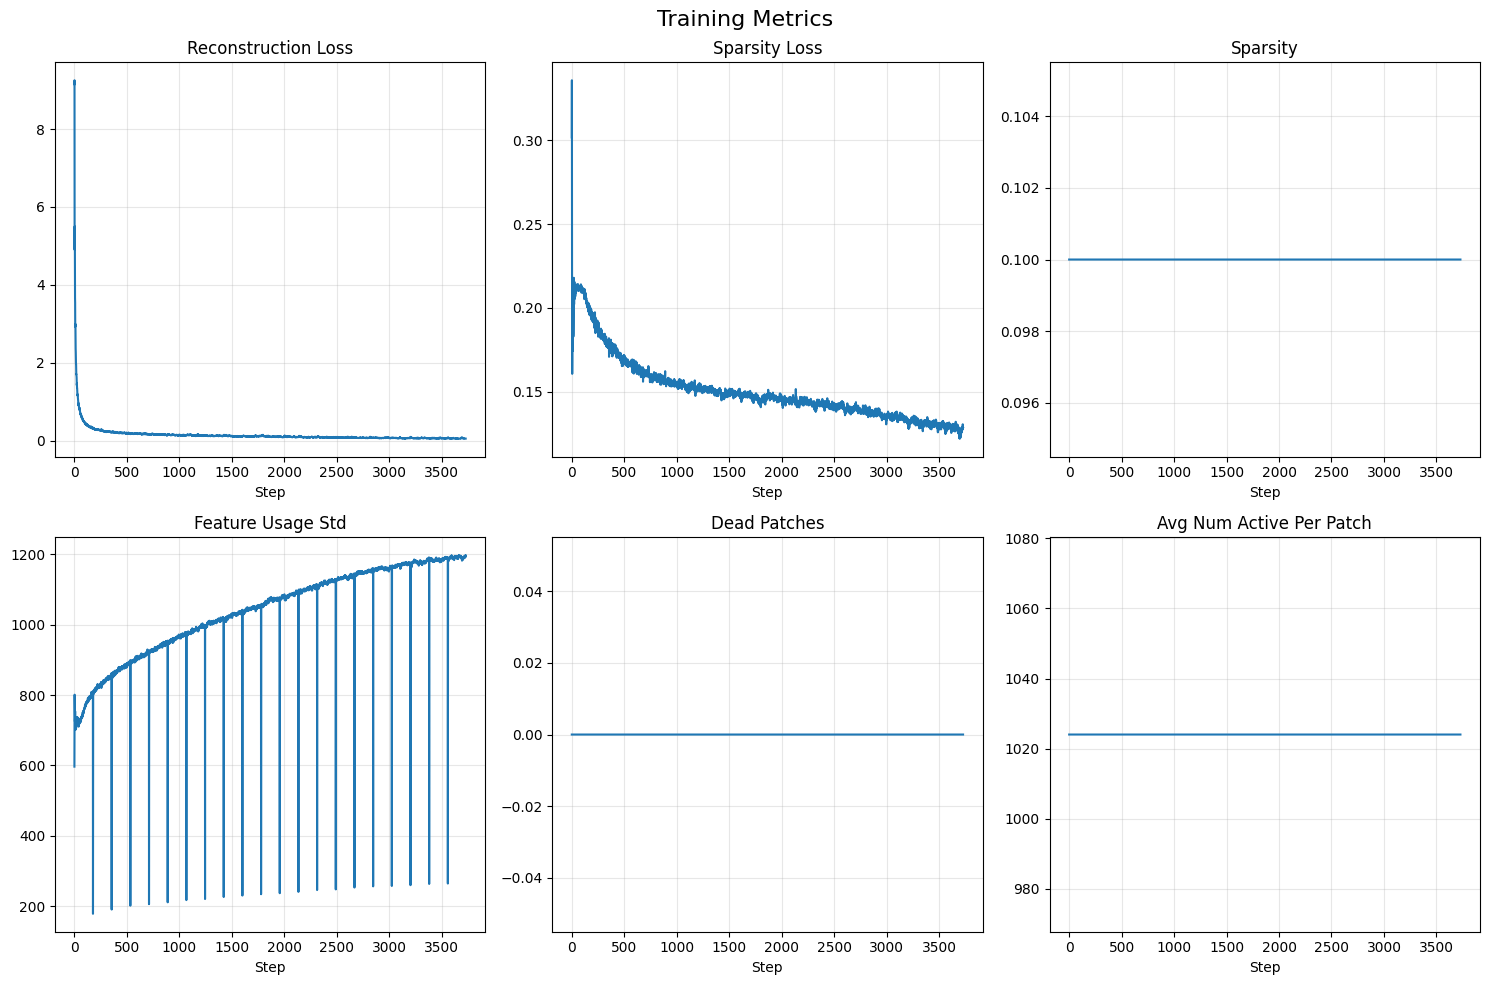

In [7]:
SAE_INPUT_DIM = 1280
SAE_HIDDEN = SAE_INPUT_DIM * 8

sae = SAE(input_dim=SAE_INPUT_DIM, hidden_dim=SAE_HIDDEN)
sae.load_state_dict(torch.load(f'{BASE_PATH}/checkpoints/sae_checkpoint_3738.pt'))
sae.to(dtype=torch.float32, device="cuda")

SAE(
  (encoder): Linear(in_features=1280, out_features=10240, bias=True)
  (decoder): Linear(in_features=10240, out_features=1280, bias=True)
)

In [8]:
df["top_cat"].value_counts()

top_cat
objects         1781
animals          696
people           394
scenery          352
abstract         290
food             112
architecture      36
vehicles          35
Name: count, dtype: int64

In [9]:
if "pipe" in globals():
  clear_gpu()
  print("Deleting pipe")
  del globals()["pipe"]
  clear_gpu()
if "all_acts" in globals():
  clear_gpu()
  print("Deleting all_acts")
  del globals()["all_acts"]
  clear_gpu()


pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")

pipe.to("cuda")

pipe.set_progress_bar_config(disable=True)

n_components = 10
CATEGORY = "animals"
SAMPLES = 200
suffix = f"{n_components},{SAE_HIDDEN}-{CATEGORY}_all"
SEED = 42

# # UNCOMMENT TO GENERATE NMF AGAIN
with torch.no_grad():
  # select n_sample images from each category
  samples = {}

  all_acts = []

  def hook(module, input, output):
      act: torch.Tensor = einops.rearrange(output.detach(), "b c h w -> b h w c")
      act = act.float()
      reconstructed, hidden = sae(act)
      all_acts.append(hidden.detach())

  prompts = df[df["top_cat"] == CATEGORY].sample(n=SAMPLES)["prompt"].tolist()
  loader = DataLoader(PromptsDataset(prompts), batch_size=18)

  for batch in tqdm(loader):
    pipe.unet.mid_block.register_forward_hook(hook)

    pipe(batch, num_inference_steps=1, guidance_scale=0.0)

    pipe.unet.mid_block._forward_hooks.clear()

# collect all acts into one and merge all patches and batches
all_acts_merged = torch.cat(all_acts, dim=0).reshape((-1, SAE_HIDDEN))

print(all_acts_merged.shape)

print(f"Final feature matrix shape: {all_acts_merged.shape}")

from sklearn.decomposition import NMF


feature_matrix = all_acts_merged.cpu().detach()
nmf = NMF(
    n_components=n_components,
    max_iter=400,
    random_state=42,  # FIX the seed for reproducibility
    verbose=1

)


# Fit with progress monitoring
W = nmf.fit_transform(feature_matrix)
H = nmf.components_



# save the above two matrices because takes a fuck ton of time to generate
np.save(f"{BASE_PATH}/NMF_W-{suffix}.npy", W)
np.save(f"{BASE_PATH}/NMF_H-{suffix}.npy", H)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

torch.Size([51200, 10240])
Final feature matrix shape: torch.Size([51200, 10240])
violation: 1.0
violation: 0.3726001340007659
violation: 0.21456289219204663
violation: 0.19808155433590607
violation: 0.13139665339352005
violation: 0.08500827003117115
violation: 0.0591198736588203
violation: 0.04485695860750612
violation: 0.03669247134078144
violation: 0.03147401422540543
violation: 0.02792448326056914
violation: 0.0253195174325957
violation: 0.023267003598062778
violation: 0.021608339997281338
violation: 0.020264460512799044
violation: 0.01917280742875586
violation: 0.018225185538673146
violation: 0.01735755687389621
violation: 0.01652888868610915
violation: 0.015745850778179308
violation: 0.014991824056651214
violation: 0.014243036349952418
violation: 0.013508653471206151
violation: 0.012810668718318189
violation: 0.012122870743133202
violation: 0.011484398281497553
violation: 0.010895606850021717
violation: 0.010347030409730796
violation: 0.00984996289066231
violation: 0.009386949142

In [10]:
# load the files instead

W = torch.from_numpy(np.load(f"{BASE_PATH}/NMF_W-{suffix}.npy")).to(device="cuda")
H = torch.from_numpy(np.load(f"{BASE_PATH}/NMF_H-{suffix}.npy")).to(device="cuda")

W.shape, H.shape

(torch.Size([51200, 10]), torch.Size([10, 10240]))

In [ ]:
# component_sparsity = (H > 0.1).sum(axis=1)  # How many features per component
# print("Features per component:", component_sparsity)

# # Look at reconstruction quality
# reconstructed = W @ H
# reconstruction_error = np.mean((all_acts_merged.cpu().numpy() - reconstructed.cpu().numpy()) ** 2)
# print(f"Reconstruction error: {reconstruction_error:.4f}")

In [11]:
component_usage = W.mean(axis=0)  # Average activation per component
print("Component usage (top 10):", component_usage.argsort()[-10:])
print("Component usage (bottom 10):", component_usage.argsort()[:10])

Component usage (top 10): tensor([0, 1, 2, 3, 4, 5, 9, 7, 6, 8], device='cuda:0')
Component usage (bottom 10): tensor([0, 1, 2, 3, 4, 5, 9, 7, 6, 8], device='cuda:0')


Let us take a default prompt, and pass it through the model.

For each component, we will pass the detault prompt through the model, and edit the activations (at a random patch of the image) to be hte component's activations.

We will get 60 (n_components) images, each one being a result of one (random) patch's activations being altered.

Lets save and look at output images for each component when we modify all 256 patches for a component, one patch at a time!

In [ ]:
import traceback
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Javascript, display
import warnings
warnings.filterwarnings('ignore', message='.*To copy construct from a tensor.*')

original_image = None
stored_output_acts = None


class PaintingInterface:
    def __init__(self, W, H, n_components):
        self.W = W
        self.H = H
        self.n_components = n_components
        self.selected_patches = set()

        # Create 16x16 grid of toggle buttons
        self.patch_buttons = []
        for i in range(256):
            btn = widgets.ToggleButton(
                description='',
                disabled=False,
                button_style='',
                layout=widgets.Layout(width='20px', height='20px')
            )
            btn.patch_idx = i

            btn.observe(self.on_patch_toggle, names='value')
            self.patch_buttons.append(btn)

        # Arrange buttons in 16x16 grid
        button_rows = []
        for row in range(16):
            row_buttons = self.patch_buttons[row*16:(row+1)*16]
            button_rows.append(widgets.HBox(row_buttons, layout=widgets.Layout(gap='2px')))

        self.button_grid = widgets.VBox(button_rows, layout=widgets.Layout(gap='2px'))

        self.input_prompt = widgets.Text(value="two dogs playing in a field in the evening sun", layout=widgets.Layout(
                border='2px solid gray',  # width style color
                border_radius='5px'      # optional rounded corners
            )
        )

        self.heatmap_output = widgets.Output(layout=widgets.Layout(width='300px', height='300px'))

        # Component selector
        self.component_slider = widgets.IntSlider(
            value=0, min=0, max=n_components-1,
            description='Component:', continuous_update=False
        )

        # Activation strength slider
        self.strength_slider = widgets.FloatSlider(
            value=5.0, min=0.0, max=20.0, step=0.5,
            description='Strength:', continuous_update=False
        )

        # Control buttons
        self.generate_btn = widgets.Button(description='Generate Image', button_style='success')
        self.clear_btn = widgets.Button(description='Clear Selection', button_style='warning')
        self.select_all_btn = widgets.Button(description='Select All')

        # Status and output
        self.status_label = widgets.Label(value='No patches selected')
        self.output = widgets.Output()
        self.heatmap_output = widgets.Output(layout=widgets.Layout(width='300px', height='300px'))

        self.component_slider.observe(self.update_heatmap, names='value')

        # Set up callbacks
        self.generate_btn.on_click(self.generate_image)
        self.clear_btn.on_click(self.clear_selection)
        self.select_all_btn.on_click(self.select_all)

        # Layout
        controls = widgets.VBox([
            widgets.Label("Enter prompt"),
            self.input_prompt,
            widgets.Label('Click or (click + drag) to paint. Click again (or shift + click + drag) to erase:'),
            self.button_grid,
            self.component_slider,
            self.strength_slider,
            widgets.HBox([self.generate_btn, self.clear_btn, self.select_all_btn]),
            self.status_label,
            widgets.Label('Component Activity Heatmap:'),
            self.heatmap_output
        ])
        self.ui = widgets.HBox([
            self.output,  # Images on left
            controls      # Controls on right
        ])

        self.full_ui = self.ui  # No need for extra VBox wrapper

    def update_heatmap(self, change=None):
      with self.heatmap_output:
          clear_output(wait=True)
          component_idx = self.component_slider.value

          # Calculate average activation per patch for this component
          this_w = self.W[:, component_idx].cpu().detach().numpy()
          samples_per_patch = this_w.shape[0] // 256
          averages_by_patch = np.zeros(256)

          for patch_idx in range(256):
              patch_activations = []
              for sample_idx in range(samples_per_patch):
                  val = this_w[sample_idx * 256 + patch_idx]
                  patch_activations.append(val)
              averages_by_patch[patch_idx] = np.mean(patch_activations)

          # Create heatmap
          fig, ax = plt.subplots(1, 1, figsize=(4, 4))
          avg_grid = averages_by_patch.reshape(16, 16)
          im = ax.imshow(avg_grid, cmap='hot', interpolation='nearest')
          ax.set_title(f'Component {component_idx} Activity')
          ax.set_xlabel('Width')
          ax.set_ylabel('Height')
          plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
          plt.tight_layout()
          plt.show()

    def on_patch_toggle(self, change):
        btn = change['owner']
        if change['new']:  # Button pressed
            self.selected_patches.add(btn.patch_idx)
            btn.button_style = 'success'
        else:  # Button released
            self.selected_patches.discard(btn.patch_idx)
            btn.button_style = ''

        self.update_status()

    def update_status(self):
        n_selected = len(self.selected_patches)
        self.status_label.value = f'{n_selected} patches selected'

    def clear_selection(self, b):
        self.selected_patches.clear()
        for btn in self.patch_buttons:
            btn.value = False
            btn.button_style = ''
        self.update_status()

    def select_all(self, b):
        for btn in self.patch_buttons:
            btn.value = True
            btn.button_style = 'success'
            self.selected_patches.add(btn.patch_idx)
        self.update_status()

    @torch.no_grad()
    def generate_image(self, b):
        if not self.input_prompt.value:
          self.input_prompt.layout.border = "2px solid red"
          self.input_prompt.placeholder = "Must enter prompt to generate image!"

          return

        self.input_prompt.layout.border = "2px solid gray"


        # if not self.selected_patches:
        #     with self.output:
        #         clear_output(wait=True)
        #         print("Please select at least one patch!")
        #     return

        with torch.no_grad():
            global original_image
            generator = torch.Generator(device="cuda").manual_seed(SEED)
            original_image = pipe(prompt=self.input_prompt.value, num_inference_steps=1, guidance_scale=0.0, generator=generator).images[0]

        with self.output:
            clear_output(wait=True)
            print(f"Generating with {len(self.selected_patches)} patches modified...")

            # Create hook for selected patches
            component_idx = self.component_slider.value
            strength = self.strength_slider.value

            # Get component activations
            c = self.H[component_idx]
            component_activations = torch.tensor(c, device="cuda") * strength

            def painting_hook(module, input, output):
                # Process activations
                act = einops.rearrange(output, "b c h w -> b h w c")
                act = act.float()

                # Get SAE hidden activations
                _, hidden = sae(act)

                # Modify selected patches
                for patch_idx in self.selected_patches:
                    x_loc = patch_idx % 16
                    y_loc = patch_idx // 16
                    hidden[0, y_loc, x_loc, :] += component_activations

                # Reconstruct
                reconstructed = sae.decoder(hidden)
                reconstructed = einops.rearrange(reconstructed, "b h w c -> b c h w")

                return reconstructed.to(dtype=torch.float16)

            # Generate image
            try:
                pipe.unet.mid_block._forward_hooks.clear()
                pipe.unet.mid_block.register_forward_hook(painting_hook)

                generator = torch.Generator(device="cuda").manual_seed(SEED)
                image = pipe(
                    prompt=self.input_prompt.value,
                    num_inference_steps=1,
                    guidance_scale=0.0,
                    generator=generator
                ).images[0]

                # Display results side by side
                fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 12))

                ax2.imshow(original_image)
                ax2.set_title('Original')
                ax2.axis('off')

                ax1.imshow(image)
                ax1.set_title(f'Modified - Component {component_idx}, Strength {strength}')
                ax1.axis('off')

                # Overlay selected patches on modified image
                for patch_idx in self.selected_patches:
                    x = (patch_idx % 16) * 32  # 512/16 = 32 pixels per patch
                    y = (patch_idx // 16) * 32
                    rect = Rectangle((x, y), 32, 32,
                                   linewidth=2, edgecolor='red', facecolor='none')
                    ax1.add_patch(rect)

                plt.tight_layout()
                plt.show()

            finally:
                pipe.unet.mid_block._forward_hooks.clear()
                torch.cuda.empty_cache()

    def display(self):
        print("Component usage (top 10):", component_usage.argsort()[-10:])
        print("Component usage (bottom 10):", component_usage.argsort()[:10])
        display(self.full_ui)
        self.update_heatmap()  # Show initial heatmap


def enable_drag_paint():
    js_code = """
    // Get all toggle buttons in the grid
    const buttons = document.querySelectorAll('.widget-toggle-button');
    let isMouseDown = false;
    let isPainting = true;  // true = paint, false = erase

    // Track mouse state globally
    document.addEventListener('mousedown', () => { isMouseDown = true; });
    document.addEventListener('mouseup', () => { isMouseDown = false; });

    document.addEventListener('keydown', (e) => {
        if (e.key === 'Shift') {
            isPainting = false;
            document.body.style.cursor = 'crosshair';  // Or 'not-allowed' for erase
        }
    });

    document.addEventListener('keyup', (e) => {
        if (e.key === 'Shift') {
            isPainting = true;
            document.body.style.cursor = 'default';
        }
    });


    buttons.forEach(button => {
        // On mouse enter while dragging
        button.addEventListener('mouseenter', (e) => {
            if (isMouseDown) {
                // Simulate click to toggle the button
                const clickEvent = new MouseEvent('click', {
                    bubbles: true,
                    cancelable: true,
                    view: window
                });

                // Check if we should paint or erase
                const isActive = button.classList.contains('mod-active');
                if (isPainting && !isActive) {
                    button.dispatchEvent(clickEvent);
                } else if (!isPainting && isActive) {
                    button.dispatchEvent(clickEvent);
                }
            }
        });

        // Prevent default drag behavior
        button.addEventListener('dragstart', (e) => e.preventDefault());
    });
    """
    display(Javascript(js_code))


painter = PaintingInterface(W, H, n_components)
painter.display()
enable_drag_paint()

Component usage (top 10): tensor([0, 1, 2, 3, 4, 5, 9, 7, 6, 8], device='cuda:0')
Component usage (bottom 10): tensor([0, 1, 2, 3, 4, 5, 9, 7, 6, 8], device='cuda:0')


<IPython.core.display.Javascript object>

In [ ]:
import traceback
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

test_prompt = "two dogs playing on a hill with bright afternoon"


# generator with fixed seed so that pipe gives us the same image everytime for a "fair" comparison of impact of components on the image
generator = torch.Generator(device="cuda").manual_seed(SEED)

stored_output_acts = None


def hook(module, input, output):
  """
  """
  global stored_output_acts
  stored_output_acts = output

  return output

pipe.unet.mid_block.register_forward_hook(hook)


with torch.no_grad():
  global original_image
  # save the original image's activations so that we don't need to restore them everytime
  original_image = pipe(prompt=test_prompt, num_inference_steps=1, guidance_scale=0.0, generator=generator).images[0]

# remove hook
pipe.unet.mid_block._forward_hooks.clear()


def create_hook(component_activations: torch.Tensor, forget_input: bool = True, patches: list[int] = [0]):
  def hook(module, input, output):
    # instead of using this specific output use the stored stuff so we use the same thing everytime
    global stored_output_acts

    act = einops.rearrange(stored_output_acts, "b c h w -> b h w c")

    act = act.float()


    outs: tuple[torch.Tensor, torch.Tensor] = sae(act)
    _, hidden = outs

    _, h, w, _ = hidden.shape

    for pi in patches:
      x_loc = pi % w
      y_loc = pi // h

      # this is dumb but lessee what happens
      hidden[0, y_loc, x_loc, :] = component_activations

    reconstructed = sae.decoder(hidden)
    # reshape
    reconstructed = einops.rearrange(reconstructed, "b h w c -> b c h w")

    # we pass back reconstructed
    return reconstructed.to(dtype=torch.float16)

  return hook

patches_modified = []
images = []
components = []

# let us artificially increase a component's SAE activations and create a custom SAE activations for us
# this can be batched but issok.
with torch.no_grad():
  for idx in tqdm(range(0, n_components)):
    components.append(idx)
    patches = np.random.randint(0, 256, 1)
    patches_modified.append(patches)
    c = H[idx]
    # this is a tensor of SAE_HIDDEN values.. each telling how much "weight" to be given to that particular SAE feature
    try:
      component_activations = torch.tensor(c, device="cuda")
      pipe.unet.mid_block.register_forward_hook(create_hook(component_activations, patches=patches))
      image = pipe(prompt=test_prompt, num_inference_steps=1, guidance_scale=0.0, generator=generator).images[0]
      images.append(image)
    except Exception as e:
      traceback.print_exc()
      print(e)
    finally:
      del component_activations
      pipe.unet.mid_block._forward_hooks.clear()
      torch.cuda.empty_cache()

def visualize_component_grid_single_random_patch(original_image, images, component_indices, patches_modified, ncols=3):
    n_images = len(images)
    # Each row shows: original | modified, so we need 2 columns per comparison
    nrows = (n_images + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols * 2, figsize=(ncols*8, nrows*4))
    axes = axes.reshape(nrows, ncols * 2) if nrows > 1 else axes.reshape(1, -1)

    for idx, (img, comp_idx) in enumerate(zip(images, component_indices)):
        row = idx // ncols
        col = (idx % ncols) * 2  # Each comparison takes 2 columns

        # Original image
        ax_orig = axes[row, col]
        ax_orig.imshow(original_image)
        ax_orig.set_title(f"Original")
        ax_orig.axis('off')

        # Modified image
        ax_mod = axes[row, col + 1]
        ax_mod.imshow(img)

        patches = patches_modified[idx]

        # Add patch indicators
        for pi in patches:
            x = (pi % 16) * (img.width / 16)
            y = (pi // 16) * (img.height / 16)
            rect = Rectangle((x, y), img.width/16, img.height/16,
                           linewidth=2, edgecolor='red', facecolor='none')
            ax_mod.add_patch(rect)

        ax_mod.set_title(f"Component {comp_idx}\nPatch: {int(patches[0])}")
        ax_mod.axis('off')

    # Hide empty subplots
    for row in range(nrows):
        for col in range(ncols * 2):
            if (row * ncols + col // 2) >= n_images:
                axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# Usage
# visualize_component_grid_single_random_patch(original_image, images, components, patches_modified, ncols=3)

  0%|          | 0/60 [00:00<?, ?it/s]

/tmp/ipython-input-14-3051691396.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  component_activations = torch.tensor(c, device="cuda")


In [ ]:
# import ipywidgets as widgets
# from IPython.display import display, clear_output
# from PIL import Image, ImageDraw
# import gc

# h = 16
# w = 16
# patches_per_image = h * w
# n_categories = len(categories)

# batch_size = 28

# test_prompt = "two dogs playing on a hill with bright afternoon"

# pipe.unet.mid_block._forward_hooks.clear()

# original_image = None

# with torch.no_grad():
#     global original_image
#     generator = torch.Generator(device="cuda").manual_seed(SEED)
#     original_image = pipe(prompt=test_prompt, num_inference_steps=1, guidance_scale=0.0, generator=generator).images[0]

# # After generating all patch_images, create and save grid with PIL only
# def save_grid_fast(patch_images, component_idx, save_path):
#     img_size = 140
#     spacing = 20  # Space between images
#     text_height = 20  # Space for text above each image

#     # Calculate grid size with spacing
#     grid_width = 16 * img_size + 15 * spacing
#     grid_height = 17 * (img_size + text_height) + 16 * spacing

#     grid_pil = Image.new('RGB', (grid_width, grid_height), color='white')  # White background

#     # Font setup
#     from PIL import ImageFont
#     try:
#         font = ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf", 14)
#     except:
#         font = ImageFont.load_default()

#     draw = ImageDraw.Draw(grid_pil)

#     # Place original with "Original" text above it
#     orig = Image.fromarray(patch_images[0]).resize((img_size, img_size))
#     draw.text((img_size//2, 5), "Original", fill='black', font=font, anchor='mt')
#     grid_pil.paste(orig, (0, text_height))

#     # Place patch images with numbers above
#     for idx in range(NUMBER_OF_PATCHES_TO_EDIT):
#         img = Image.fromarray(patch_images[idx + 1])
#         img_resized = img.resize((img_size, img_size))

#         row = (idx // 16) + 1
#         col = idx % 16

#         # Calculate position with spacing
#         x_pos = col * (img_size + spacing)
#         y_pos = row * (img_size + text_height + spacing)

#         # Draw patch number above image
#         text_x = x_pos + img_size // 2
#         text_y = y_pos - 5
#         draw.text((text_x, text_y), str(idx), fill='black', font=font, anchor='mb')

#         # Draw red rectangle on the image
#         img_draw = ImageDraw.Draw(img_resized)
#         patch_x = (idx % 16) * (img_resized.width // 16)
#         patch_y = (idx // 16) * (img_resized.height // 16)
#         img_draw.rectangle(
#             [patch_x, patch_y, patch_x + img_resized.width//16, patch_y + img_resized.height//16],
#             outline='red', width=2
#         )

#         # Paste image
#         grid_pil.paste(img_resized, (x_pos, y_pos))

#     grid_pil.save(f'{save_path}_grid.png', optimize=True, quality=95)


# def visualize_component(component_idx: int, W, generate_grid: bool = False, mode: str = "EXPLORER"):
#     global h
#     global w
#     global patches_per_image
#     global batch_size
#     global n_categories
#     global original_image

#     # hook fn
#     def create_batch_hook(component_activations, patch_indices):
#       def hook(module, input, output):
#           global stored_output_acts
#           batch_size = output.shape[0]

#           results = []

#           # Process each batch item separately - just like your working single hook!
#           for b_idx in range(batch_size):
#               # Use stored_output_acts for each item
#               act = einops.rearrange(stored_output_acts, "b c h w -> b h w c")
#               act = act.float()

#               # Process through SAE
#               _, hidden = sae(act)
#               _, h, w, _ = hidden.shape

#               # Modify specific patch
#               pi = patch_indices[b_idx]
#               x_loc = pi % w
#               y_loc = pi // h
#               hidden[0, y_loc, x_loc, :] = 5 * component_activations

#               # Reconstruct
#               reconstructed = sae.decoder(hidden)
#               reconstructed = einops.rearrange(reconstructed, "b h w c -> b c h w")
#               results.append(reconstructed)

#           # Stack all results
#           return torch.cat(results, dim=0).to(dtype=torch.float16)

#       return hook

#     explore_mode = mode == "EXPLORER"

#     component_activations_by_patch: dict[int, np.ndarray] = {}
#     averages_by_patch = np.zeros((patches_per_image, ))

#     this_w = W[:, component_idx].cpu().detach()
#     samples_per_patch = this_w.shape[0] // (h * w)

#     # Calculate category-wise means
#     W_entries_per_cat = SAMPLES_PER_CATEGORY * h * w
#     category_means = {}

#     for category_idx, category in enumerate(categories):
#         start_idx = category_idx * W_entries_per_cat
#         end_idx = (category_idx + 1) * W_entries_per_cat
#         entries = this_w[start_idx:end_idx]
#         category_means[category] = entries.mean()

#     # Find top category
#     sorted_cats = sorted(category_means.items(), key=lambda x: x[1], reverse=True)
#     top_category = sorted_cats[0][0]
#     selectivity = sorted_cats[0][1] / sorted_cats[1][1] if sorted_cats[1][1] > 0 else float('inf')

#     for patch_idx in range(patches_per_image):
#         component_activations_by_patch[patch_idx] = []
#         for sample_idx in range(samples_per_patch):
#             val = this_w[sample_idx * patches_per_image + patch_idx]
#             component_activations_by_patch[patch_idx].append(val)

#         component_activations_by_patch[patch_idx] = np.array(component_activations_by_patch[patch_idx])
#         averages_by_patch[patch_idx] = component_activations_by_patch[patch_idx].mean()

#     top_40_patches = np.argsort(averages_by_patch)[-40:]

#     # Adjust figure layout for better grid display
#     if generate_grid and explore_mode:
#         fig = plt.figure(figsize=(24, 48))  # Much taller figure if exploring (we also have to show. if not exploring, we save separately so keep 12)
#         gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 8], hspace=0.2, wspace=0.15)  # Changed from 6 to 3 rows
#     else:
#         fig = plt.figure(figsize=(20, 12))
#         gs = fig.add_gridspec(2, 2)



#     # 1. Line chart with category means
#     ax1 = fig.add_subplot(gs[0, 0])

#     # Plot patch activations
#     for patch_idx in range(0, patches_per_image):
#         acts = component_activations_by_patch[patch_idx]
#         ax1.plot(acts, alpha=0.3, color='gray', linewidth=0.5)

#     # Add category means as horizontal lines
#     colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
#     for i, (category, mean_val) in enumerate(category_means.items()):
#         start_x = i * SAMPLES_PER_CATEGORY
#         end_x = (i + 1) * SAMPLES_PER_CATEGORY - 1
#         ax1.hlines(mean_val, start_x, end_x, colors=colors[i], linewidth=3,
#                    label=f'{category}: {mean_val:.4f}')

#     ax1.set_xlabel('Image Index')
#     ax1.set_ylabel('Activation Value')
#     ax1.set_title(f"Component {component_idx}: Patch activations with category means\n" +
#                   f"Top category: {top_category} (selectivity: {selectivity:.2f})")

#     # Set x-axis ticks
#     category_centers = [4 + i * SAMPLES_PER_CATEGORY for i in range(n_categories)]
#     ax1.set_xticks(category_centers)
#     ax1.set_xticklabels(categories, rotation=45, ha='right')

#     # Add vertical lines
#     for i in range(1, 8):
#         ax1.axvline(x=i*SAMPLES_PER_CATEGORY - 4, color='gray', linestyle='--', alpha=0.3)

#     # 2. Heatmap of average activation by patch position
#     ax2 = fig.add_subplot(gs[0, 1])
#     avg_grid = averages_by_patch.reshape(h, w)
#     im = ax2.imshow(avg_grid, cmap='hot', interpolation='nearest')
#     ax2.set_title(f'Component {component_idx}: Average Activation by Patch Position')
#     ax2.set_xlabel('Width')
#     ax2.set_ylabel('Height')
#     plt.colorbar(im, ax=ax2)

#     # 3. Binary grid showing top 40 most active patches
#     ax3 = fig.add_subplot(gs[1, 0])
#     top_40_grid = np.zeros((h, w))
#     for pi in top_40_patches:
#         y, x = pi // w, pi % w
#         top_40_grid[y, x] = 1

#     ax3.imshow(top_40_grid, cmap='RdBu_r', interpolation='nearest')
#     ax3.set_title(f'Component {component_idx}: Top 40 Most Active Patches')
#     ax3.set_xlabel('Width')
#     ax3.set_ylabel('Height')

#     # 4. Bar chart of category means
#     ax4 = fig.add_subplot(gs[1, 1])
#     cats = list(category_means.keys())
#     means = list(category_means.values())
#     bars = ax4.bar(cats, means, color=colors[:len(cats)])
#     ax4.set_xlabel('Category')
#     ax4.set_ylabel('Mean Activation')
#     ax4.set_title(f'Component {component_idx}: Mean Activation by Category')
#     ax4.tick_params(axis='x', rotation=45)

#     # Highlight top category
#     max_idx = np.argmax(means)
#     bars[max_idx].set_edgecolor('red')
#     bars[max_idx].set_linewidth(3)

#     save_path = f'{BASE_PATH}/component_{component_idx}'

#     if generate_grid:
#         if explore_mode:
#           ax5 = fig.add_subplot(gs[2, :])
#           ax5.set_title(f'Component {component_idx}: All 256 Patch Modifications', fontsize=20, pad=30)
#           # First, display the original image at the top
#           ax5.text(0.5, 0.98, 'Original Image', transform=ax5.transAxes,
#                   ha='center', va='top', fontsize=14, fontweight='normal')

#         print(f"Generating 256 patch grid for component {component_idx}...")

#         # Get component activations
#         c = H[component_idx]
#         component_activations = torch.tensor(c, device="cuda")

#         # Create a grid that includes space for original image
#         patch_images = []

#         # Add original image first
#         patch_images.append(np.array(original_image))

#         # Process in batches
#         for batch_start in tqdm(range(0, NUMBER_OF_PATCHES_TO_EDIT, batch_size), desc=f"Batch generation for component {component_idx}"):
#             batch_end = min(batch_start + batch_size, NUMBER_OF_PATCHES_TO_EDIT)
#             batch_patches = list(range(batch_start, batch_end))
#             current_batch_size = len(batch_patches)

#             try:
#                 # Create prompts for batch
#                 prompts = [test_prompt] * current_batch_size

#                 # Register batch hook
#                 pipe.unet.mid_block.register_forward_hook(
#                     create_batch_hook(component_activations, batch_patches)
#                 )
#                 with torch.no_grad():
#                     images = pipe(
#                         prompt=prompts,
#                         num_inference_steps=1,
#                         guidance_scale=0.0,
#                         generator=torch.Generator(device="cuda").manual_seed(SEED)
#                     ).images

#                 # Add to patch_images
#                 patch_images.extend([np.array(img) for img in images])

#             except Exception as e:
#                 print(f"Error in batch {batch_start}-{batch_end}: {e}")
#                 # Add blank images for failed batch
#                 for _ in range(current_batch_size):
#                     patch_images.append(np.zeros((512, 512, 3), dtype=np.uint8))

#             finally:
#                 pipe.unet.mid_block._forward_hooks.clear()
#                 clear_gpu()

#             # Clear cache periodically
#             if batch_start % n_components == 0:
#                 torch.cuda.empty_cache()

#         # Create grid with original + 256 patches (17x16 grid)
#         # Replace the grid creation section with:

#         # Create grid with original + 256 patches (17x16 grid)
#         img_size = 140
#         spacing = 20  # Space between images
#         text_height = 20  # Space for text above each image

#         grid_rows = 17
#         grid_cols = 16

#         # Calculate total grid size with spacing
#         grid_width = grid_cols * img_size + (grid_cols - 1) * spacing
#         grid_height = grid_rows * (img_size + text_height) + (grid_rows - 1) * spacing

#         # Create white background
#         grid = np.ones((grid_height, grid_width, 3), dtype=np.uint8) * 255

#         # Place original image with text
#         orig_pil = Image.fromarray(patch_images[0])
#         orig_resized = orig_pil.resize((img_size, img_size), Image.Resampling.LANCZOS)
#         grid[text_height:text_height+img_size, 0:img_size] = np.array(orig_resized)

#         # Place patch images
#         for idx in range(NUMBER_OF_PATCHES_TO_EDIT):
#             img = patch_images[idx + 1]
#             row = (idx // 16) + 1
#             col = idx % 16

#             # Calculate position with spacing
#             x_start = col * (img_size + spacing)
#             y_start = row * (img_size + text_height + spacing) + text_height

#             img_pil = Image.fromarray(img)
#             img_resized = img_pil.resize((img_size, img_size), Image.Resampling.LANCZOS)

#             # Place image in grid
#             grid[y_start:y_start+img_size, x_start:x_start+img_size] = np.array(img_resized)

#         if explore_mode:
#             # Display the grid
#             ax5.imshow(grid, aspect='equal')
#             ax5.axis('off')

#             # Add text labels above each image
#             # Original label
#             ax5.text(img_size//2, 10, "Original", color='black', fontsize=14,
#                     weight='normal', ha='center', va='center')

#             # Patch numbers
#             for idx in range(NUMBER_OF_PATCHES_TO_EDIT):
#                 row = (idx // 16) + 1
#                 col = idx % 16

#                 # Text position above each image
#                 text_x = col * (img_size + spacing) + img_size // 2
#                 text_y = row * (img_size + text_height + spacing) + 10

#                 ax5.text(text_x, text_y, str(idx), color='black', fontsize=12,
#                         weight='normal', ha='center', va='center')

#                 # Red rectangle on the patch
#                 rect_x = col * (img_size + spacing) + (idx % 16) * (img_size / 16)
#                 rect_y = row * (img_size + text_height + spacing) + text_height + (idx // 16) * (img_size / 16)

#                 rect = Rectangle((rect_x, rect_y), img_size/16, img_size/16,
#                               linewidth=1, edgecolor='red', facecolor='none')
#                 ax5.add_patch(rect)


#         if explore_mode:
#           # Display the grid
#           ax5.imshow(grid, aspect='equal')
#           ax5.axis('off')

#         # Clean up
#         if not explore_mode:
#           save_grid_fast(patch_images, component_idx, save_path)

#         del component_activations
#         del patch_images


#     plt.suptitle(f'Component {component_idx} Analysis\n' +
#                  f'Max patch avg: {averages_by_patch.max():.4f}, ' +
#                  f'Spatial variance: {avg_grid.std():.4f}', fontsize=16)

#     if explore_mode:
#         # plt.tight_layout()
#         plt.show()
#     else:
#         # if generate_grid:
#         #     save_path += '_with_grid'

#         plt.savefig(save_path + '_analysis.png', dpi=100, bbox_inches='tight')
#         plt.close(fig)


#     plt.close(fig)

# class ComponentExplorer:
#     def __init__(self, W, n_components, initial_checkbox_value:bool = False):
#         self.W = W
#         self.n_components = n_components
#         self.current_idx = 0

#         # Create widgets
#         self.prev_button = widgets.Button(description='← Previous')
#         self.next_button = widgets.Button(description='Next →')
#         self.component_slider = widgets.IntSlider(
#             value=0,
#             min=0,
#             max=n_components-1,
#             step=1,
#             description='Component:',
#             continuous_update=False
#         )
#         self.generate_grid_checkbox = widgets.Checkbox(
#             value=initial_checkbox_value,
#             description='Generate 256 Patch Grid',
#             disabled=False
#         )
#         self.output = widgets.Output()

#         # Set up callbacks
#         self.prev_button.on_click(self.prev_component)
#         self.next_button.on_click(self.next_component)
#         self.component_slider.observe(self.on_slider_change, names='value')
#         self.generate_grid_checkbox.observe(self.on_grid_change, names='value')

#         # Layout
#         self.ui = widgets.VBox([
#             widgets.HBox([self.prev_button, self.next_button, self.component_slider]),
#             self.generate_grid_checkbox,
#             self.output
#         ])

#     def prev_component(self, b):
#         if self.current_idx > 0:
#             self.current_idx -= 1
#             self.component_slider.value = self.current_idx
#             self.update_display()

#     def next_component(self, b):
#         if self.current_idx < self.n_components - 1:
#             self.current_idx += 1
#             self.component_slider.value = self.current_idx
#             self.update_display()

#     def on_slider_change(self, change):
#         self.current_idx = change['new']
#         self.update_display()

#     def on_grid_change(self, change):
#         self.update_display()

#     def update_display(self):
#         with self.output:
#             clear_output(wait=True)
#             visualize_component(self.current_idx, self.W,
#                                generate_grid=self.generate_grid_checkbox.value, mode="EXPLORER")

#     def display(self):
#         display(self.ui)
#         self.update_display()




# NUMBER_OF_PATCHES_TO_EDIT = 256
# # can be "SAVE_IMAGES" which will just save plots to drive
# # can be "EXPLORER" which will start up the interactive explorer above
# exploration_type = "NONE"
# plt.close()

# component_usage = W.mean(axis=0)  # Average activation per component

# if exploration_type == "EXPLORER":
#   print("Component usage (top 10):", component_usage.argsort()[-10:])
#   print("Component usage (bottom 10):", component_usage.argsort()[:10])
#   # Create and display the explorer
#   explorer = ComponentExplorer(W, n_components=n_components, initial_checkbox_value=False)
#   explorer.display()
# if exploration_type == "SAVE_IMAGES":
#     plt.ioff()
#     for i in tqdm(range(n_components)):
#         try:
#             clear_gpu()
#             visualize_component(i, W, generate_grid=True, mode="SAVE_IMAGES")
#         except Exception as e:
#             print(f"Error on component {i}: {e}")
#         finally:
#             clear_gpu()

#     plt.ion()

Let us also look at component activation patterns...

How are the activation values of a component distributed

and also how they are distributed among each patch

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


MIN_ACT = 0.001

def plot_component_activation_histograms(W, component_indices=None, bins=50):
    """Plot histograms of activation values for each component"""

    if component_indices is None:
        component_indices = range(W.shape[1])

    n_components = len(component_indices)
    ncols = 5
    nrows = (n_components + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4*nrows))
    axes = axes.flatten() if n_components > 1 else [axes]

    for idx, comp_idx in enumerate(component_indices):
        ax = axes[idx]

        # Get activations for this component
        activations = W[:, comp_idx]

        # Plot histogram

        # remove < MIN_ACT activations when plotting
        counts, bins, _ = ax.hist(activations, bins=bins, color='blue', alpha=0.7, edgecolor='black')
        # Add statistics
        mean_act = activations.mean()
        max_act = activations.max()
        sparsity = (activations > MIN_ACT).mean() * 100  # % of patches with meaningful activation

        # mean activation value only when present
        num_active = len(activations[activations > MIN_ACT])
        only_presence_act = f"{activations[activations > MIN_ACT].mean():.1f}" if num_active else "never significantly active"

        ax.axvline(mean_act, color='red', linestyle='--', label=f'Mean: {mean_act:.3f}')
        ax.set_title(f'Component {comp_idx}\nMax: {max_act:.3f}, Active in: {sparsity:.1f}% patches, \n Mean act: {mean_act:.3f}, Only presence act: {only_presence_act}')
        ax.set_xlabel('Activation Value')
        ax.set_ylabel('Count')

        # Mark if it's a "specialist" (few high activations) or "generalist" (many low activations)
        # max_act > mean_act * 5 basically measures "when it is present, it is real high. because the denom of the mean has pushed it down"
        if sparsity < 20 and max_act > mean_act * 5:
            ax.text(0.7, 0.9, 'SPECIALIST', transform=ax.transAxes,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.5))
        elif sparsity > 50:
            ax.text(0.7, 0.9, 'GENERALIST', transform=ax.transAxes,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.5))

    # Hide empty subplots
    for idx in range(n_components, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('component_activation_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Usage - compare your top and bottom components
bottom_15 = np.argsort(component_usage)[:15]
top_10 = np.argsort(component_usage)[-10:]

print("Bottom 15 (cause chaos):")
plot_component_activation_histograms(W, bottom_15)

print("\nTop 10 (commonly used):")
plot_component_activation_histograms(W, top_10)

Hmm, so it seems like all our "bottom" aka lowest value in terms of activation components, are also present in very very few patches!

But they also have very low max values


While, the "top 10" components have higher max values, and are present in a LOT of patches.

This is even stranger! The "value" of the activation seems to not matter at all.

We replaced each of the components above in one of the patches (checkout the above eiffel grid) but nothing happened.

While the bottom-10 components: we replace it in one single patch, (note that they already had such low activations) and nothign changed.

It seems like the bottom-10 components being "active" is a much higher signal to the model than the top 10 components.

Alllmost feels like a information theory surprisal thing! Cool!

In [ ]:
# let us look at all the components now and see what we get:
print(f"All {len(component_usage)} components (sorted in descending order by their average activations)")
plot_component_activation_histograms(W, np.argsort(component_usage)[::-1])

Lol. it seems like there are many more specialist components than generalist (at least as per our thresholds).

Changing the generalist components doesn't seem to do anything..

While changing the specialist ones causes chaos because the model loses all meaning of what is the image about.

Also means that if the specialist component is present, then the model seems ot give it a LOT OF value.

Let us also look at which patches each of the 50 components is most active in.
Perhaps there is a pattern there?

Alright well...

Some components _seem_ like they only activate for certain patches and some have clear preferential categories.

Let us find the category specialists

In [ ]:
stored_output_acts.shape

In [ ]:
# find the category specialists
h = 16
w = 16

W_entries_per_cat = SAMPLES_PER_CATEGORY * h * w

component_activation_by_cats = {}

for component_idx in range(n_components):
  c = W[:, component_idx].detach().cpu()
  component_activation_by_cats[component_idx] = {
      "values": {}
  }

  for category_idx, category in enumerate(categories):
    # group these in batches of 8 (we got 8 samples from each category)
    # and calculate means of all those cats
    # for batch in range(0, len(c))
    start_idx = category_idx * W_entries_per_cat
    end_idx = (category_idx + 1) * W_entries_per_cat

    entries = c[start_idx:end_idx]
    component_activation_by_cats[component_idx]["values"][category] = {
        "entries": np.array(entries),
        "mean": entries.mean(),
        "count": len(entries)
    }


  component_activation_by_cats[component_idx]["means"] = np.array([x["mean"] for x in component_activation_by_cats[component_idx]["values"].values()])
  component_means = component_activation_by_cats[component_idx]["means"]

  component_activation_by_cats[component_idx]["std"] = np.std(component_means)
  component_activation_by_cats[component_idx]["var"] = np.var(component_means)

  # selectivity = ratio of highest and second highest mean
  sorted_means = np.sort(component_means)
  sorted_cats = [categories[cidx] for cidx in np.argsort(component_means)]
  component_activation_by_cats[component_idx]["selectivity"] = sorted_means[-1] / sorted_means[-2]
  component_activation_by_cats[component_idx]["sorted_cats"] = sorted_cats



  # we get coeff of variation because we will compare across datasets
  component_activation_by_cats[component_idx]["c_var"] = component_activation_by_cats[component_idx]["std"] * 100 / np.mean(component_activation_by_cats[component_idx]["means"])


In [ ]:
# Create the bar plot and capture the bars
bars = plt.bar(list(range(n_components)), [component_activation_by_cats[cidx]["selectivity"] for cidx in range(n_components)])

# Add text labels above each bar
for i, bar in enumerate(bars):
    top_cat = component_activation_by_cats[i]["sorted_cats"][-1][:2]
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{i}-{top_cat}',  # Format to 2 decimal places
             ha='center', va='bottom', fontsize=8)

plt.xlabel('Component Index')
plt.ylabel('Selectivity')
plt.title('Component Selectivity Scores')
plt.xticks(rotation=45)  # Optional: rotate x labels if crowded
plt.tight_layout()
plt.show()


In [ ]:
storage = {
    "sae_hidden": None
}


def hook(module, input, output):
  # we pass the output of this layer into our sae
  act = einops.rearrange(output, "b c h w -> b h w c")
  act = act.float()

  # this is batch x height x width x 1280
  sae_outs = sae(act)
  storage["sae_hidden"] = sae_outs[1]

  return output


# # generate one image
pipe.unet.mid_block._forward_hooks.clear()
pipe.unet.mid_block.register_forward_hook(hook)
image = pipe(prompt=garbage_prompt, num_inference_steps=1, guidance_scale=0.0).images[0]
pipe.unet.mid_block._forward_hooks.clear()

# pass this same image through the unet
# but changing a specific component for all the patches everytime
top2 = np.argsort(component_usage)[-2:]
bottom2 = np.argsort(component_usage)[:2]

h = 16
w = 16

n_patches = 256
for component_idx in top2:
  for patch_idx in range(0, n_patches):
    x_loc = patch_idx % h
    y_loc = patch_idx // w

    # (sae_dim, )
    C = H[component_idx]
    C = torch.tensor(C, device="cuda")

    # edit the sae_hidden with this components's weights
    label = f"Top component: {component_idx}, patch: {patch_idx}"
    this_sae_hidden = storage["sae_hidden"].clone().detach()
    this_sae_hidden[:, x_loc, y_loc, :] = C

    # now get a reconstructed image from our sae using the above hidden acts
    reconstructed = sae.decoder(this_sae_hidden).to(dtype=torch.float16)

    # pass this reconstructed through the pipe's unet's resnets
    out = pipe.unet.up_blocks(reconstructed)

    print(out)

    del this_sae_hidden
    break
  break


# patches_modified = []
# images = []
# components = []

# # let us artificially increase a component's SAE activations and create a custom SAE activations for us
# for idx in tqdm(range(0, 50)):
#   components.append(idx)
#   patches = np.random.randint(0, 256, 1)
#   patches_modified.append(patches)
#   c = H[idx]
#   # this is a tensor of SAE_HIDDEN values.. each telling how much "weight" to be given to that particular SAE feature
#   try:
#     component_activations = torch.tensor(c, device="cuda")



#     images.append(image)
#   except Exception as e:
#     traceback.print_exc()
#     print(e)
#   finally:
#     pipe.unet.mid_block._forward_hooks.clear()